In [1]:
%run mammo_utils.py

In [2]:
os.environ.setdefault('MAMMO_DATA_ROOT', r'C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16')
print('MAMMO_DATA_ROOT =', os.environ['MAMMO_DATA_ROOT'])

MAMMO_DATA_ROOT = C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16


### <font color='orange'> Preprocessing (/!\skip if done once)

In [ ]:
df = collect_png_paths(os.environ['MAMMO_DATA_ROOT'])
df['class'] = df['class'].replace({'normal': 0, 'benign': 1, 'cancer': 1})
print(df.head())
print(f"\nTotal images found: {len(df)}")

                                                path  class
0  C:\Users\Invite\Documents\INRIA\MCDropout\arch...      0
1  C:\Users\Invite\Documents\INRIA\MCDropout\arch...      0
2  C:\Users\Invite\Documents\INRIA\MCDropout\arch...      0
3  C:\Users\Invite\Documents\INRIA\MCDropout\arch...      0
4  C:\Users\Invite\Documents\INRIA\MCDropout\arch...      0

Total images found: 7810


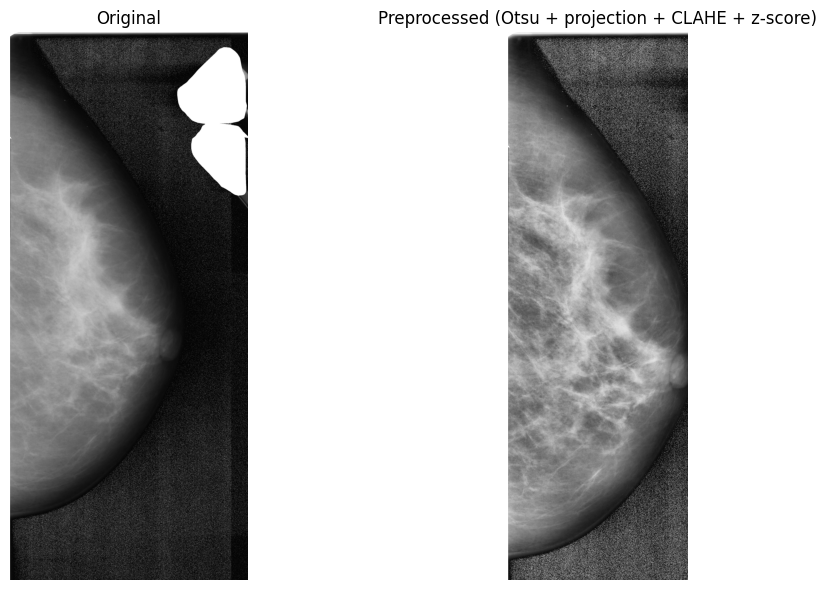

In [9]:
_ = preprocess_and_display_mammogram(df["path"].sample(1).iloc[0])

In [10]:
output_root = os.path.join(os.environ['MAMMO_DATA_ROOT'], 'processed_v3')
preprocessed_df = preprocess_all_mammos(df, output_root, overwrite=False)
preprocessed_df.to_csv("preprocessed_mammos.csv", index=False)


100%|██████████| 7810/7810 [38:55<00:00,  3.34it/s]  


In [4]:
mean, std = compute_mean_std(preprocessed_df.preprocessed_path)
print(f"Dataset mean: {mean}, std: {std}")

100%|██████████| 7810/7810 [04:49<00:00, 27.00it/s]

Dataset mean: [0.26755342], std: [0.24556606]


### <font color='orange'> Loading data for training

In [3]:
mean, std = 0.26755342, 0.24556606

In [4]:
preprocessed_df =  pd.read_csv("preprocessed_mammos.csv")

In [5]:
train_val_df, test_df = train_test_split(preprocessed_df, train_size=0.9, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_val_df, train_size=0.9, test_size=0.1, random_state=42)

In [6]:
train_dataset = MammogramDataset(train_df, mode="train", mean=mean, std=std)
val_dataset = MammogramDataset(val_df, mode="test", mean=mean, std=std)
test_dataset = MammogramDataset(test_df, mode="test", mean=mean, std=std)

train_sampler = custom_sampler(train_dataset)
val_sampler = custom_sampler(val_dataset)
test_sampler = custom_sampler(test_dataset)

train_loader = DataLoader(train_dataset, batch_size=10, sampler=train_sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=10, sampler=val_sampler, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=10, sampler=test_sampler, num_workers=0, pin_memory=True)

### <font color='orange'> Training ResNet-18 for three-classes (normal, benign, cancer) classif. task

In [13]:
model = build_resnet18_grayscale(num_classes=2)

In [14]:
model, history = train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=100,
    lr=5e-4,
    use_amp=True,
    train_info_path="C:/Users/Invite/Documents/INRIA/resnet_training/training_history.pkl",
    ckpts_path="C:/Users/Invite/Documents/INRIA/resnet_training/",
)

Starting epoch 1/100...
training...


100%|██████████| 633/633 [06:37<00:00,  1.59it/s]


validating...


100%|██████████| 71/71 [00:29<00:00,  2.43it/s]


Epoch [1/100] LR=0.000500 | Train loss=0.6729 acc=0.5906 | Val loss=1.0260 acc=0.4097
Starting epoch 2/100...
training...


...

Epoch [99/100] LR=0.000000 | Train loss=0.4627 acc=0.7646 | Val loss=0.8071 acc=0.6131
Starting epoch 100/100...
training...


100%|██████████| 633/633 [06:37<00:00,  1.59it/s]


validating...


100%|██████████| 71/71 [00:28<00:00,  2.48it/s]


Epoch [100/100] LR=0.000000 | Train loss=0.4699 acc=0.7545 | Val loss=0.8092 acc=0.6216


### <font color='orange'> Check perfs on test set

In [20]:
epochs_info = pickle.load(open("C:/Users/Invite/Documents/INRIA/resnet_training/training_history.pkl", "rb"))
epochs_info = pd.DataFrame(epochs_info).sort_values(by=['val_acc','val_loss'], ascending=False)
epochs_info

,epoch,train_loss,train_acc,val_loss,val_acc,lr,ckpt_path
71,72,0.526309,0.749447,1.527368,0.650071,0.000091,C:/Users/Invite/Documents/INRIA/resnet_trainin...
73,74,0.521573,0.755296,1.197347,0.648649,0.000079,C:/Users/Invite/Documents/INRIA/resnet_trainin...
53,54,0.587627,0.720202,0.887856,0.647226,0.000219,C:/Users/Invite/Documents/INRIA/resnet_trainin...
87,88,0.484564,0.779007,1.396670,0.645804,0.000018,C:/Users/Invite/Documents/INRIA/resnet_trainin...
82,83,0.491304,0.768258,1.495162,0.644381,0.000035,C:/Users/Invite/Documents/INRIA/resnet_trainin...
...,...,...,...,...,...,...,...
4,5,0.822008,0.543313,1.005039,0.423898,0.000497,C:/Users/Invite/Documents/INRIA/resnet_trainin...
2,3,0.863309,0.529561,1.176712,0.421053,0.000499,C:/Users/Invite/Documents/INRIA/resnet_trainin...
3,4,0.836176,0.529402,1.375425,0.376956,0.000498,C:/Users/Invite/Documents/INRIA/resnet_trainin...
5,6,0.814001,0.541100,1.649190,0.372688,0.000496,C:/Users/Invite/Documents/INRIA/resnet_trainin...


In [24]:
ckpt_path = 'C:/Users/Invite/Documents/INRIA/resnet_training/epoch_054.pth'

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = build_resnet18_grayscale(num_classes=2)
model.load_state_dict(torch.load(ckpt_path)['model_state'])
model = model.to(device)

In [ ]:
# accuracy, AUC, PRAUC, max F1